<a href="https://colab.research.google.com/github/jiq-star/UTS-DATMN-2304020029/blob/main/UTS%20DATA%20MINING%202304020029.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Persiapan Data**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
train = pd.read_csv('/content/data_training.csv')
train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918
...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0,4,1467
853,8.0,0.390,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0,5,1533
854,7.4,0.350,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9,6,1580
855,7.9,0.570,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5,6,1216


In [5]:
data_testing= pd.read_csv('/content/data_testing.csv')
data_testing

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.610,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.840,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.580,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.480,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.600,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516
...,...,...,...,...,...,...,...,...,...,...,...,...
281,10.0,0.410,0.45,6.2,0.071,6.0,14.0,0.99702,3.21,0.49,11.800000,1147
282,10.6,0.830,0.37,2.6,0.086,26.0,70.0,0.99810,3.16,0.52,9.900000,296
283,7.9,0.885,0.03,1.8,0.058,4.0,8.0,0.99720,3.36,0.33,9.100000,170
284,7.3,0.670,0.02,2.2,0.072,31.0,92.0,0.99566,3.32,0.68,11.066667,1439


**2. pembersihan data**

In [6]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
None


Berdasarkan hasil tersebut, kita dapat melihat banyaknya data, nama-nama variabel, tipe data setiap kolom, serta keberadaan nilai yang hilang (missing value).

In [7]:
print(train.describe())
print(train.isnull().sum())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count     857.000000        857.000000   857.000000      857.000000   
mean        8.261960          0.529393     0.267351        2.506184   
std         1.701992          0.179162     0.195144        1.293512   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.395000     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.600000          1.580000     1.000000       15.500000   

        chlorides  free sulfur dioxide  total sulfur dioxide     density  \
count  857.000000           857.000000            857.000000  857.000000   
mean     0.086830            15.782964             45.978413    0.996692   
std      0.048721            10.300402             31.692113    0.001901   
min      0.012000             1.000000              6.00

 Dari hasil yang telah dilakukan, dataset tidak memiliki missing value sehingga tidak diperlukan penghapusan data

**3. pembuatan model**

In [8]:
x = train.drop(['quality','Id'], axis=1)
y = train['quality']

x_test_final=data_testing.drop(['Id'],axis=1)

In [9]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x, y,
test_size=0.2,
random_state=42,
stratify=y
)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
test_scaled = scaler.transform(x_test_final)

model K-Nearest Neighbor (KNN)

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(x_train_scaled, y_train)

y_pred_knn = knn.predict(x_val_scaled)

print("Akurasi KNN:", accuracy_score(y_val, y_pred_knn))
print(classification_report(y_val, y_pred_knn))

Akurasi KNN: 0.48255813953488375
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.54      0.59      0.56        73
           6       0.46      0.43      0.44        68
           7       0.48      0.50      0.49        22
           8       0.00      0.00      0.00         3

    accuracy                           0.48       172
   macro avg       0.25      0.25      0.25       172
weighted avg       0.47      0.48      0.48       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
cm_knn = confusion_matrix(y_val, y_pred_knn)

print("Confusion Matrix KNN:")
print(cm_knn)

Confusion Matrix KNN:
[[ 0  0  0  1  0  0]
 [ 0  0  5  0  0  0]
 [ 0  5 43 24  1  0]
 [ 0  1 29 29  9  0]
 [ 0  0  3  8 11  0]
 [ 0  0  0  1  2  0]]


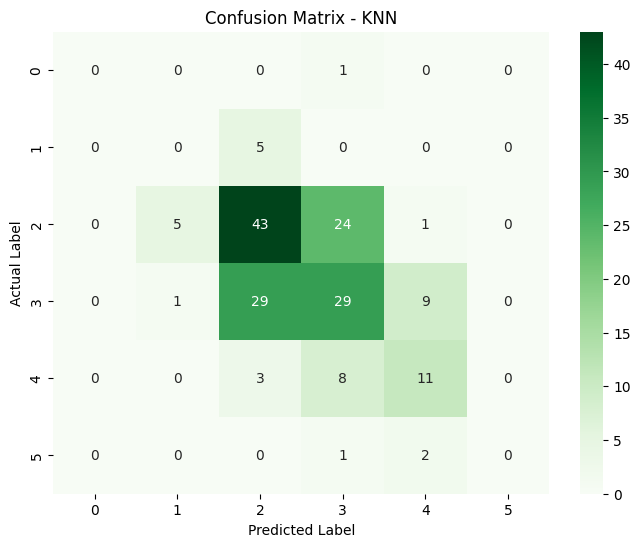

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - KNN')

plt.show()

Pada confusion matrix, baris merepresentasikan kelas sebenarnya, sementara kolom merepresentasikan kelas yang diprediksi oleh model. Nilai pada diagonal matrix menunjukkan jumlah prediksi yang tepat; semakin tinggi nilai diagonal, semakin baik performa model. Sebaliknya, nilai di luar diagonal menandakan kesalahan klasifikasi, contohnya data dengan kualitas tertentu diprediksi sebagai kelas kualitas lain yang dekat. Dari hasil confusion matrix pada model K-Nearest Neighbor (KNN), masih terlihat beberapa kesalahan prediksi di antara kelas kualitas yang berdekatan. Hal ini terjadi karena KNN mengklasifikasikan data berdasarkan kedekatan jarak dengan sejumlah tetangga terdekat yang digunakan dalam proses prediksi.

model random forest

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(x_train, y_train)
y_pred_rf=rf.predict(x_val)
print ("Akurasi Random Forest", accuracy_score(y_val, y_pred_rf))
print (classification_report(y_val, y_pred_rf))

Akurasi Random Forest 0.6569767441860465
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.70      0.84      0.76        73
           6       0.62      0.66      0.64        68
           7       0.50      0.27      0.35        22
           8       1.00      0.33      0.50         3

    accuracy                           0.66       172
   macro avg       0.47      0.35      0.38       172
weighted avg       0.63      0.66      0.63       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred_rf)

print("Confusion Matrix Random Forest:")
print(cm)

Confusion Matrix Random Forest:
[[ 0  0  1  0  0  0]
 [ 0  0  5  0  0  0]
 [ 0  0 61 11  1  0]
 [ 0  0 20 45  3  0]
 [ 0  0  0 16  6  0]
 [ 0  0  0  0  2  1]]


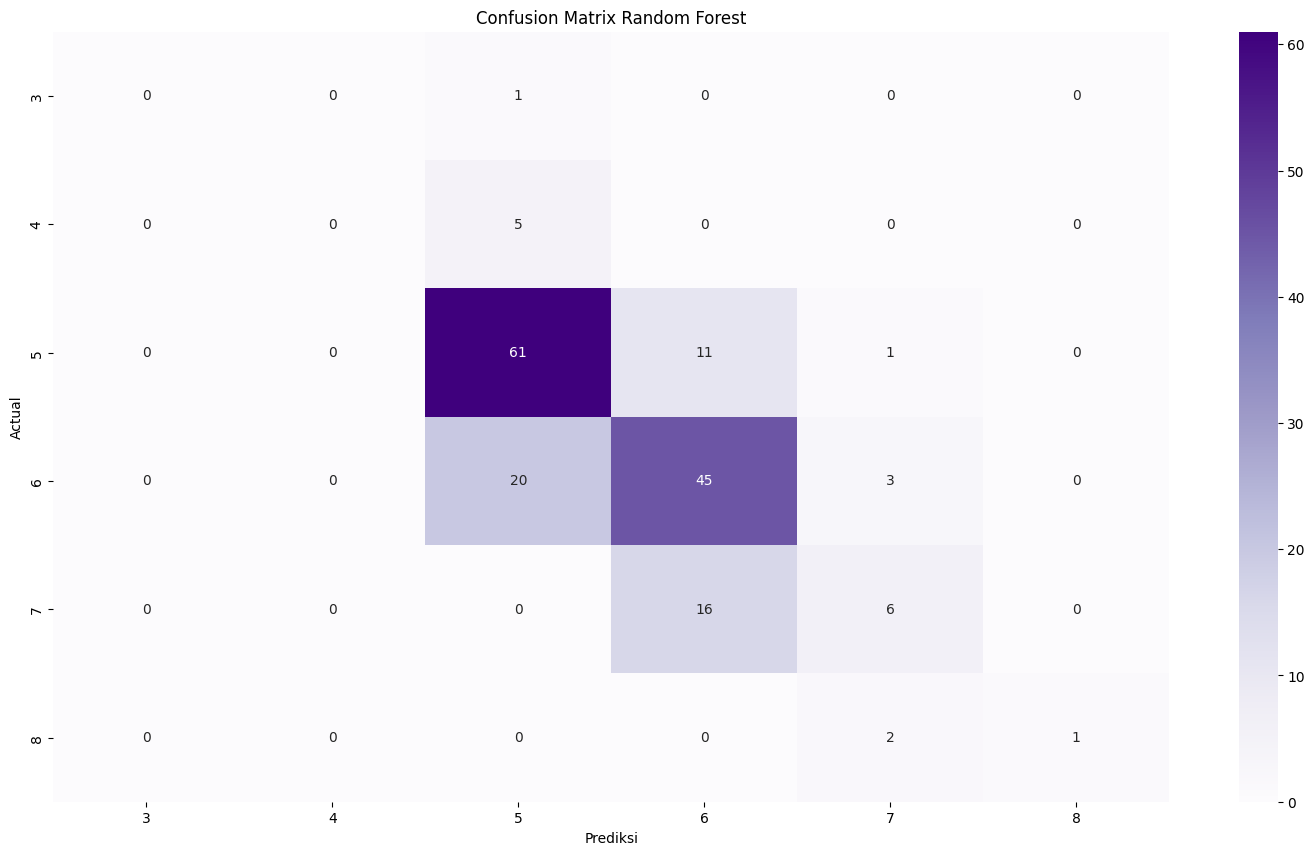

In [16]:
labels = sorted(y.unique())

plt.figure(figsize=(18,10))
sns.heatmap(cm, annot=True, cmap='Purples', fmt='d',
           xticklabels=labels, yticklabels=labels)
plt.xlabel('Prediksi')
plt.ylabel('Actual')
plt.title('Confusion Matrix Random Forest')
plt.show()

Pada confusion matrix untuk model Random Forest, baris menunjukkan kelas aktual, sedangkan kolom menunjukkan kelas yang diprediksi oleh model. Nilai pada diagonal menunjukkan jumlah prediksi yang tepat, sehingga semakin tinggi nilai diagonal, semakin baik performa model. Hasil confusion matrix menunjukkan bahwa model Random Forest mampu memberikan prediksi lebih akurat dibandingkan model sebelumnya, karena jumlah prediksi yang benar pada diagonal lebih dominan dan kesalahan klasifikasi lebih sedikit. Namun, masih terdapat beberapa kesalahan prediksi pada kelas kualitas yang berdekatan nilainya, yang disebabkan oleh karakteristik data antar kelas yang memiliki pola hampir serupa, sehingga model kadang kesulitan membedakan beberapa kelas tertentu.

model decision tree

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(random_state=42)

dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_val)

print("Akurasi Decision Tree:", accuracy_score(y_val, y_pred_dt))
print(classification_report(y_val, y_pred_dt))

Akurasi Decision Tree: 0.6046511627906976
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.66      0.74      0.70        73
           6       0.61      0.56      0.58        68
           7       0.58      0.50      0.54        22
           8       0.50      0.33      0.40         3

    accuracy                           0.60       172
   macro avg       0.39      0.36      0.37       172
weighted avg       0.60      0.60      0.60       172



In [18]:
cm_dt = confusion_matrix(y_val, y_pred_dt)

print("Confusion Matrix Decision Tree:")
print(cm_dt)

Confusion Matrix Decision Tree:
[[ 0  0  1  0  0  0]
 [ 0  0  2  3  0  0]
 [ 2  2 54 13  2  0]
 [ 1  1 23 38  4  1]
 [ 0  1  2  8 11  0]
 [ 0  0  0  0  2  1]]


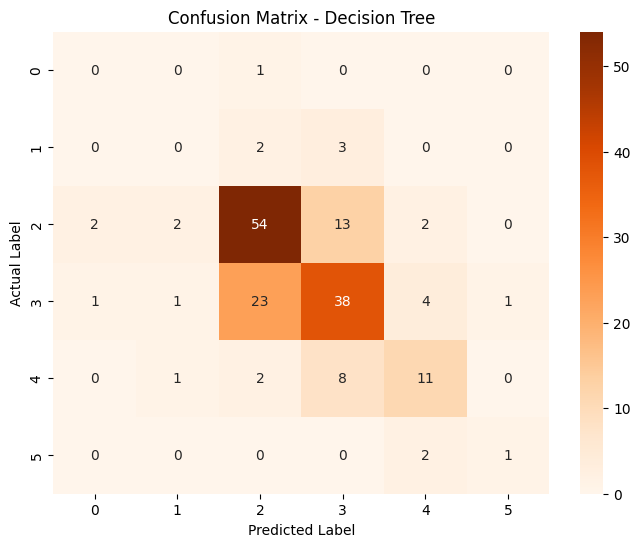

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Decision Tree')

plt.show()

Berdasarkan confusion matrix pada model Decision Tree, terlihat bahwa model mampu melakukan klasifikasi pada beberapa kelas quality dengan cukup baik, yang ditunjukkan oleh nilai pada diagonal yang merepresentasikan jumlah prediksi yang benar. Namun, jika dibandingkan dengan model Random Forest, Decision Tree masih menunjukkan lebih banyak kesalahan klasifikasi pada beberapa kelas kualitas, terutama pada kelas dengan nilai yang berdekatan. Hal ini menandakan bahwa model Decision Tree masih mengalami kesulitan membedakan pola data antar kelas tertentu. Selain itu, Decision Tree cenderung lebih rentan terhadap overfitting, karena model membentuk aturan keputusan secara detail berdasarkan data pelatihan. Meski begitu, model ini tetap memberikan performa klasifikasi yang cukup baik dalam memprediksi kualitas anggur berdasarkan fitur-fitur kimiawi yang tersedia.

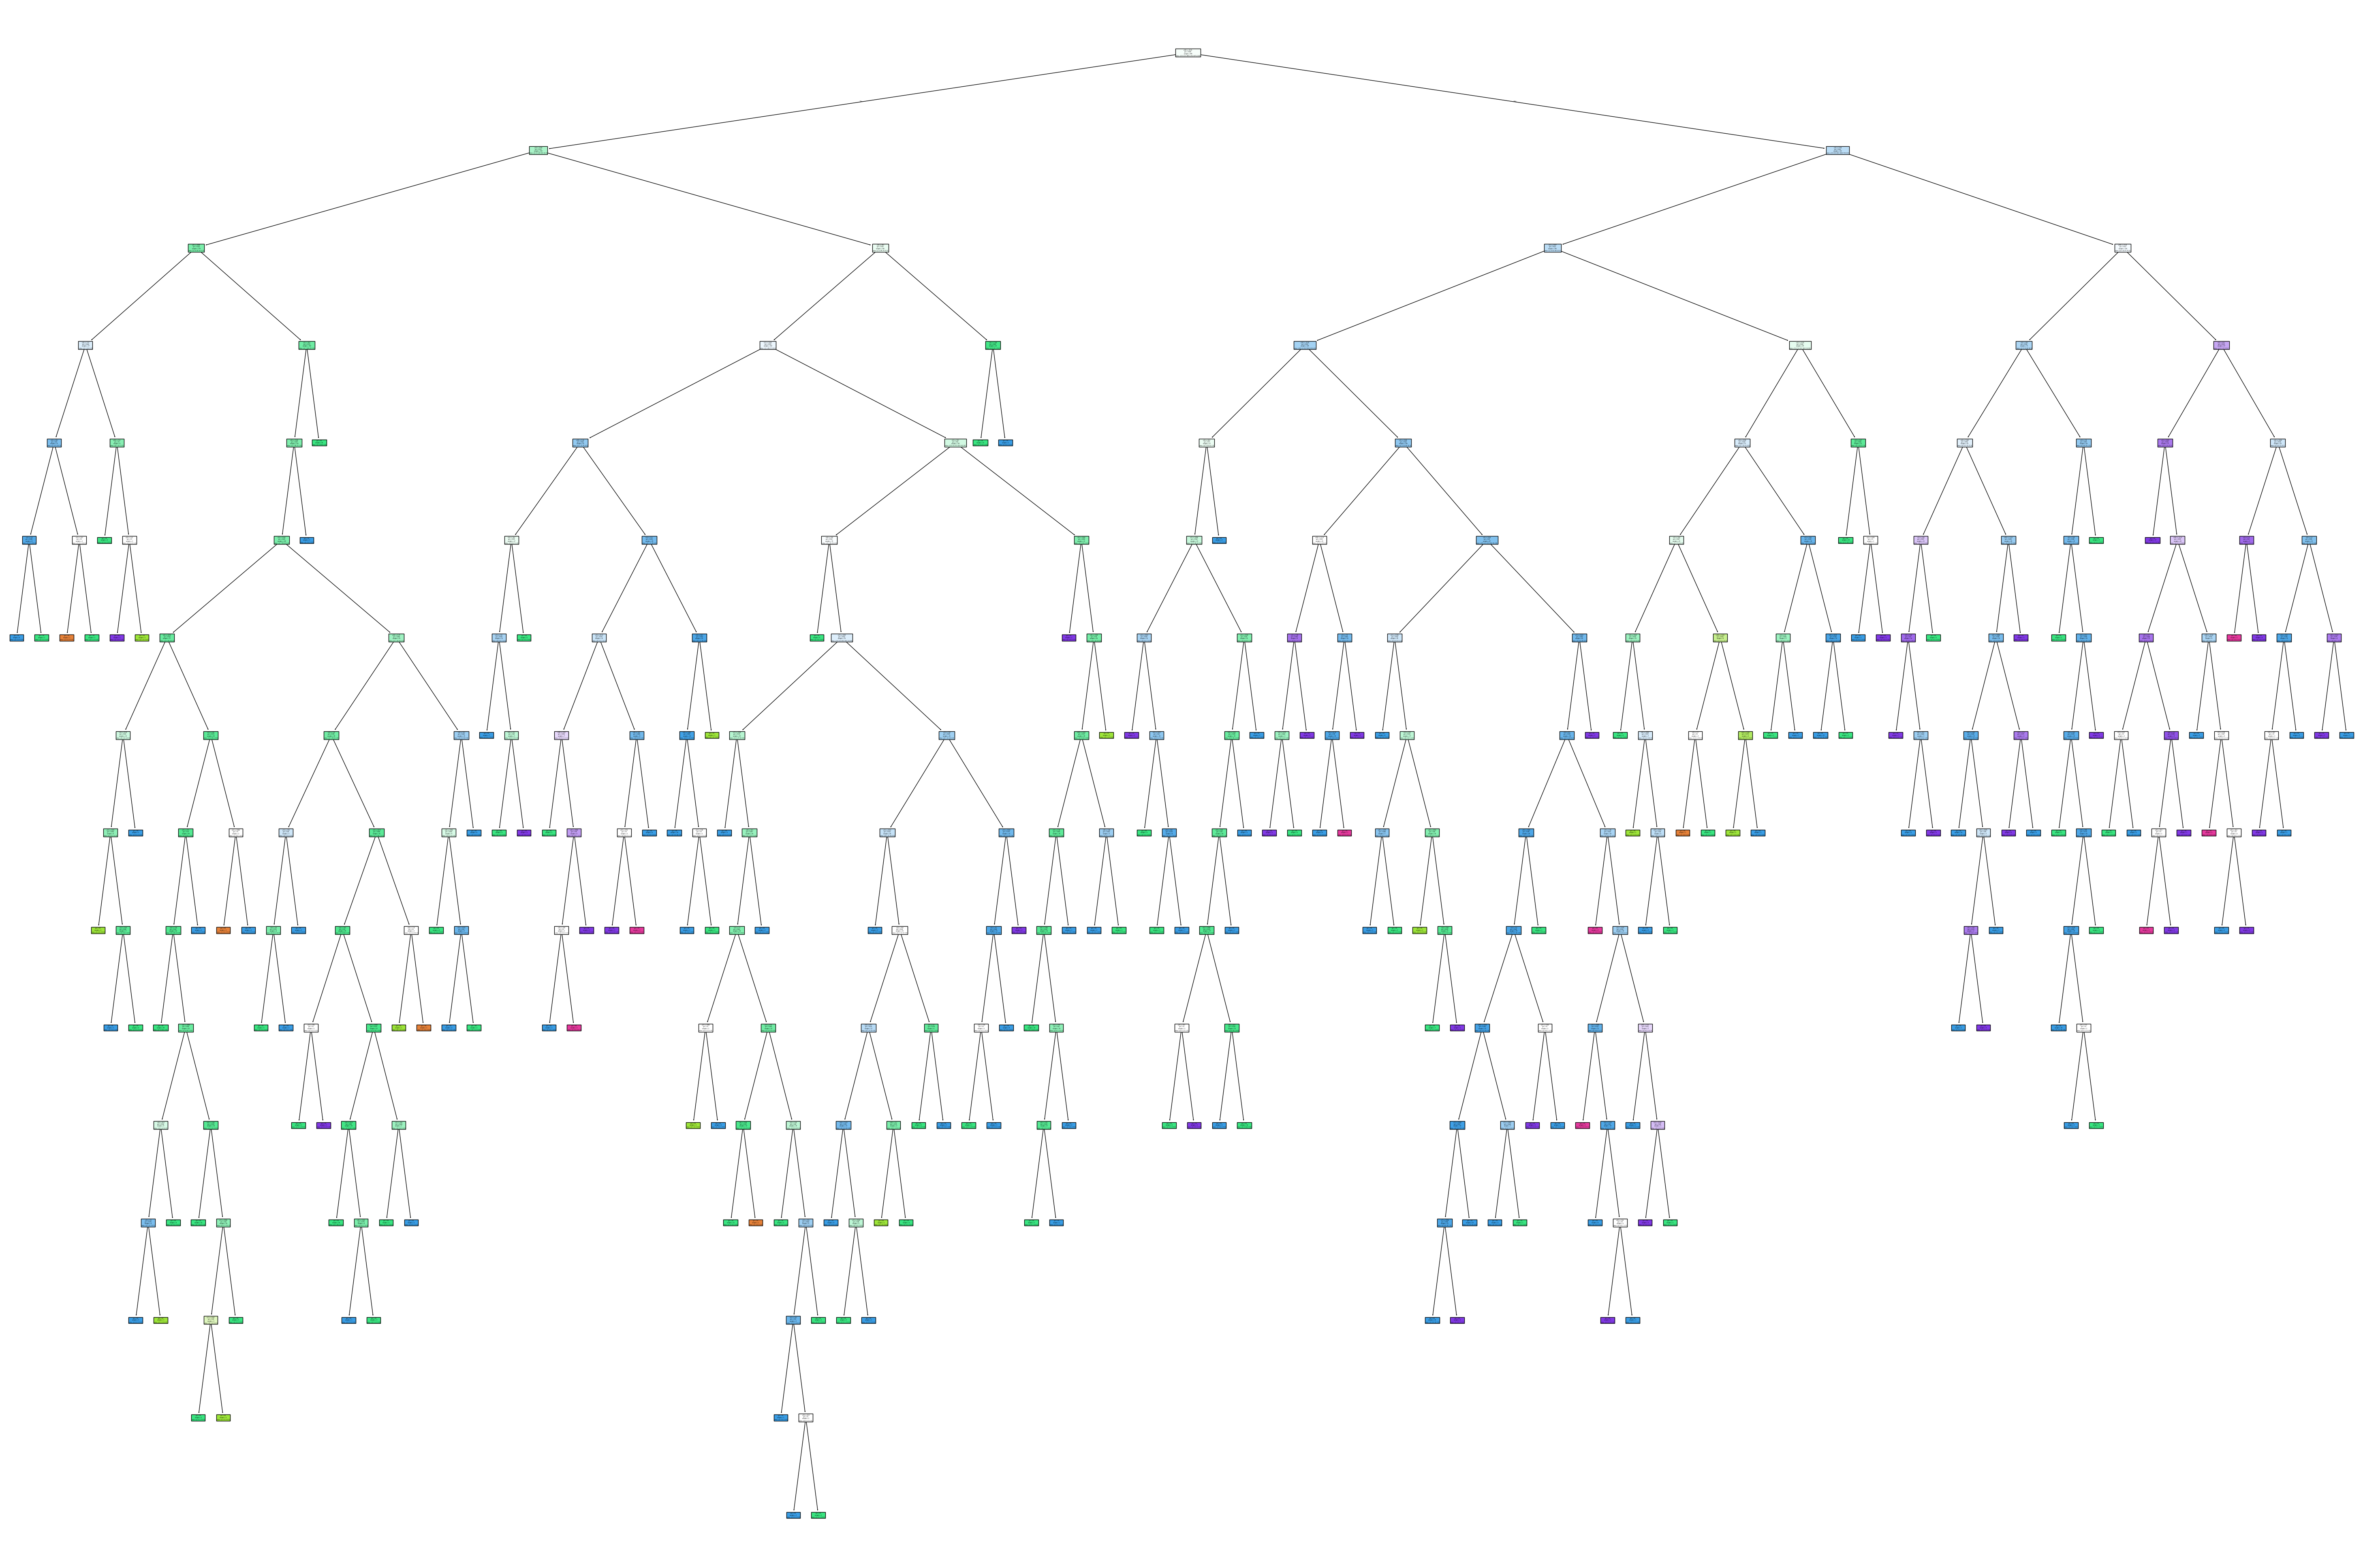

In [20]:
from sklearn.tree import plot_tree
plt.figure(figsize = (75,50))
plot_tree(dt.fit(x_train, y_train), filled=True)
plt.show()

membandingkan akurasi model

In [21]:
akurasi_knn = accuracy_score(y_val, y_pred_knn)
akurasi_rf = accuracy_score(y_val, y_pred_rf)
akurasi_dt = accuracy_score(y_val, y_pred_dt)

hasil_model = pd.DataFrame({
    'Model': ['KNN', 'Random Forest', 'Decision Tree'],
    'Akurasi': [akurasi_knn, akurasi_rf, akurasi_dt]
})

hasil_model

,Model,Akurasi
0,KNN,0.482558
1,Random Forest,0.656977
2,Decision Tree,0.604651


Dari ketiga model klasifikasi di atas, diperoleh model terbaik adalah Random Forest.

Gunakan model terbaik yaitu random forest

In [22]:
model_terbaik = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
model_terbaik.fit(scaler.transform(x), y)

RandomForestClassifier(class_weight='balanced', random_state=42)

**4. Predikasi hasil**

In [23]:
prediksi_quality = model_terbaik.predict(test_scaled)
hasil_prediksi = pd.DataFrame({
    'Id': data_testing['Id'],
    'quality': prediksi_quality
})

hasil_prediksi

,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5
...,...,...
281,1147,6
282,296,5
283,170,5
284,1439,5


In [24]:
hasil_prediksi.to_csv('hasilprediksi_029.csv', index=False)